# 🏦 Home Credit Default Risk
## Phase 1 — EDA | Phase 2 — Baseline Model

> **Goal:** Understand the data deeply before modeling. Every chart answers a business question.
> Every decision is documented. This notebook is the single source of truth for our baseline.

---

## 📦 0. Imports & Config

In [1]:
# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
from sklearn.base import BaseEstimator, TransformerMixin

# ── LightGBM ──────────────────────────────────────────────────────────────────
import lightgbm as lgb

# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
DATA_PATH    = '/kaggle/input/competitions/home-credit-default-risk/'

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE = {'repaid': '#2ecc71', 'default': '#e74c3c'}

print('✅ Imports done')

✅ Imports done


---
# 🔍 PHASE 1 — Exploratory Data Analysis
---

## 1.1 — First Contact with the Data

In [2]:
# Load only the main table for Phase 1 & 2
train = pd.read_csv(DATA_PATH + 'application_train.csv')
test  = pd.read_csv(DATA_PATH + 'application_test.csv')

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
print(f'\nMemory usage: {train.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Train shape : (307511, 122)
Test shape  : (48744, 121)

Memory usage: 529.5 MB


In [3]:
# Column type breakdown
num_cols = train.select_dtypes(include=['number']).columns.tolist()
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

# Remove target and ID from num_cols
num_cols = [c for c in num_cols if c not in ['TARGET', 'SK_ID_CURR']]

print(f'Numerical columns  : {len(num_cols)}')
print(f'Categorical columns: {len(cat_cols)}')
print(f'\nFirst 5 rows:')
train.head()

Numerical columns  : 104
Categorical columns: 16

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Statistical summary — spot anomalies immediately
train[num_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
CNT_CHILDREN,307511.000000,0.417052,0.722121,0.000000,0.000000,0.000000,1.000000,19.000000
AMT_INCOME_TOTAL,307511.000000,168797.919297,237123.146279,25650.000000,112500.000000,147150.000000,202500.000000,117000000.000000
AMT_CREDIT,307511.000000,599025.999706,402490.776996,45000.000000,270000.000000,513531.000000,808650.000000,4050000.000000
AMT_ANNUITY,307499.000000,27108.573909,14493.737315,1615.500000,16524.000000,24903.000000,34596.000000,258025.500000
AMT_GOODS_PRICE,307233.000000,538396.207429,369446.460540,40500.000000,238500.000000,450000.000000,679500.000000,4050000.000000
REGION_POPULATION_RELATIVE,307511.000000,0.020868,0.013831,0.000290,0.010006,0.018850,0.028663,0.072508
DAYS_BIRTH,307511.000000,-16036.995067,4363.988632,-25229.000000,-19682.000000,-15750.000000,-12413.000000,-7489.000000
DAYS_EMPLOYED,307511.000000,63815.045904,141275.766519,-17912.000000,-2760.000000,-1213.000000,-289.000000,365243.000000
DAYS_REGISTRATION,307511.000000,-4986.120328,3522.886321,-24672.000000,-7479.500000,-4504.000000,-2010.000000,0.000000
DAYS_ID_PUBLISH,307511.000000,-2994.202373,1509.450419,-7197.000000,-4299.000000,-3254.000000,-1720.000000,0.000000


## 1.2 — Target Distribution (Class Imbalance)

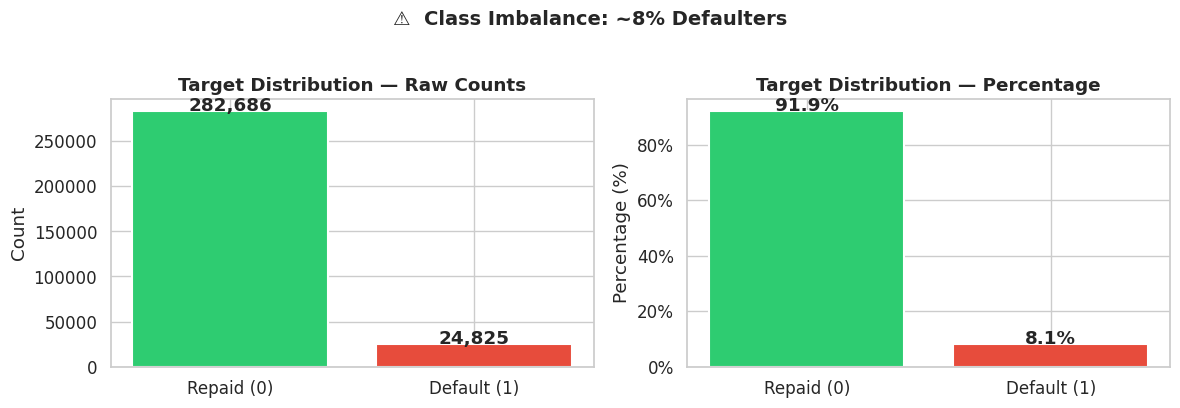


💡 Real-World Note:
   8% default rate is realistic for consumer lending.
   → Always use stratified CV to preserve this ratio in every fold.
   → AUC-ROC is robust to imbalance. Accuracy is NOT a valid metric here.
   → In production: rejecting a good customer (FP) vs approving a bad one (FN)
     have very different business costs. We will revisit threshold tuning in Phase 4.


In [5]:
target_counts = train['TARGET'].value_counts()
target_pct    = train['TARGET'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
colors = [PALETTE['repaid'], PALETTE['default']]
axes[0].bar(['Repaid (0)', 'Default (1)'], target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution — Raw Counts', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
axes[1].bar(['Repaid (0)', 'Default (1)'], target_pct.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Target Distribution — Percentage', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(target_pct.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('⚠️  Class Imbalance: ~8% Defaulters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 💡 Real-world note
print('\n💡 Real-World Note:')
print('   8% default rate is realistic for consumer lending.')
print('   → Always use stratified CV to preserve this ratio in every fold.')
print('   → AUC-ROC is robust to imbalance. Accuracy is NOT a valid metric here.')
print('   → In production: rejecting a good customer (FP) vs approving a bad one (FN)')
print('     have very different business costs. We will revisit threshold tuning in Phase 4.')

## 1.3 — Missing Value Analysis

Columns with missing values: 67 / 122


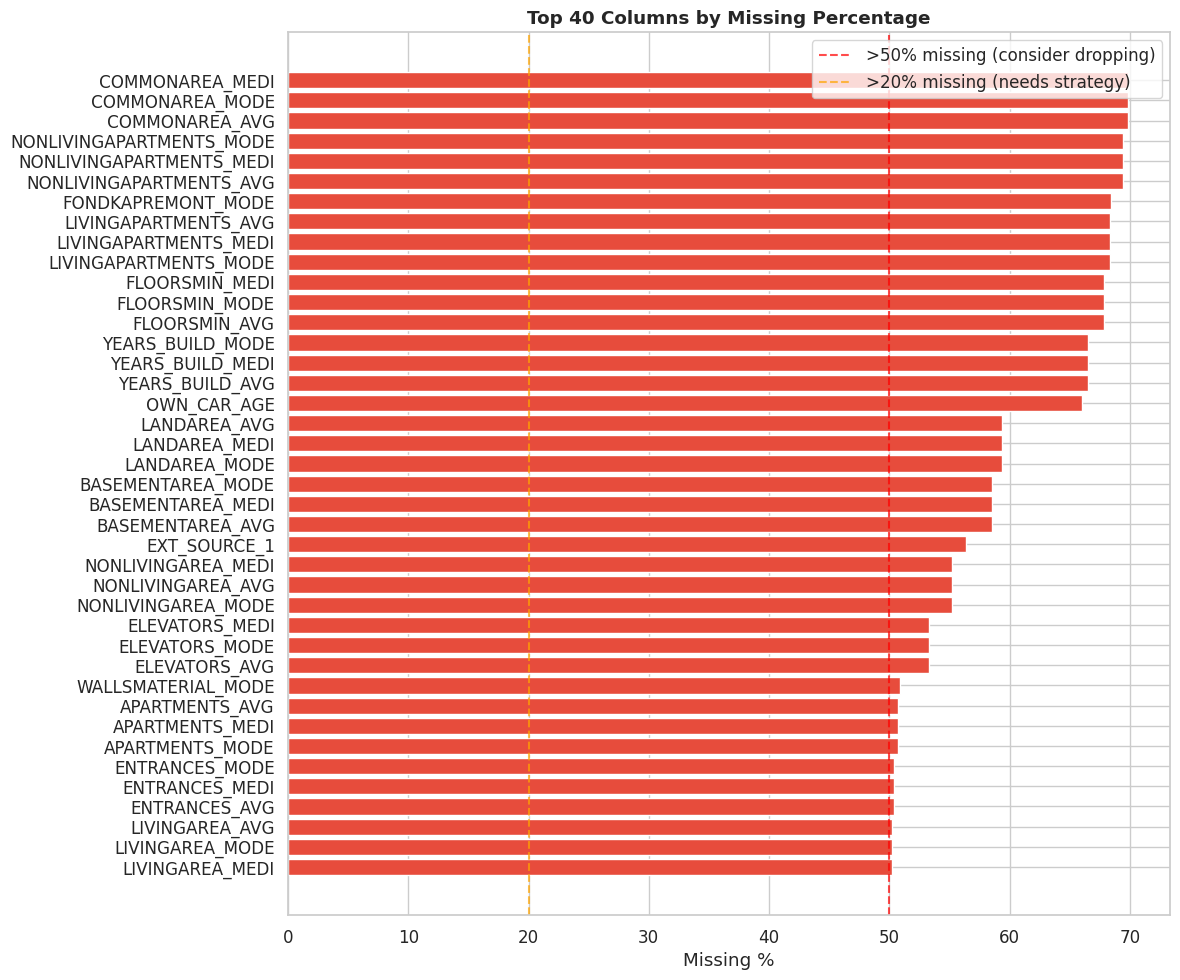


Columns with >40% missing:


,missing_count,missing_pct,dtype
COMMONAREA_MEDI,214865,69.87,float64
COMMONAREA_MODE,214865,69.87,float64
COMMONAREA_AVG,214865,69.87,float64
NONLIVINGAPARTMENTS_MODE,213514,69.43,float64
NONLIVINGAPARTMENTS_MEDI,213514,69.43,float64
NONLIVINGAPARTMENTS_AVG,213514,69.43,float64
FONDKAPREMONT_MODE,210295,68.39,object
LIVINGAPARTMENTS_AVG,210199,68.35,float64
LIVINGAPARTMENTS_MEDI,210199,68.35,float64
LIVINGAPARTMENTS_MODE,210199,68.35,float64


In [6]:
def missing_report(df):
    """Returns a sorted DataFrame of missing value statistics."""
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    report = pd.DataFrame({
        'missing_count' : miss,
        'missing_pct'   : (miss / len(df) * 100).round(2),
        'dtype'         : df[miss.index].dtypes
    })
    return report

miss_report = missing_report(train)
print(f'Columns with missing values: {len(miss_report)} / {train.shape[1]}')

# Visualize top 40 missing columns
top_missing = miss_report.head(40)
fig, ax = plt.subplots(figsize=(12, 10))
colors_bar = ['#e74c3c' if p > 50 else '#e67e22' if p > 20 else '#3498db'
              for p in top_missing['missing_pct']]
bars = ax.barh(top_missing.index, top_missing['missing_pct'], color=colors_bar)
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='>50% missing (consider dropping)')
ax.axvline(20, color='orange', linestyle='--', alpha=0.7, label='>20% missing (needs strategy)')
ax.set_xlabel('Missing %')
ax.set_title('Top 40 Columns by Missing Percentage', fontweight='bold')
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

# Show the full report for high-missing columns
print('\nColumns with >40% missing:')
miss_report[miss_report['missing_pct'] > 40]

In [7]:
# Does missingness correlate with default rate? (Real-world key question)
print('💡 Missingness vs Default Rate')
print('   Missing data is rarely random in credit risk.')
print('   A missing EXT_SOURCE score often means no credit history → higher risk.\n')

key_missing_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
                    'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'OCCUPATION_TYPE']

miss_vs_target = pd.DataFrame()
for col in key_missing_cols:
    if col in train.columns:
        is_missing = train[col].isnull()
        default_rate_missing    = train.loc[is_missing,  'TARGET'].mean() * 100
        default_rate_not_missing = train.loc[~is_missing, 'TARGET'].mean() * 100
        miss_vs_target = pd.concat([miss_vs_target, pd.DataFrame({
            'feature'              : [col],
            'default_rate_missing' : [round(default_rate_missing, 2)],
            'default_rate_present' : [round(default_rate_not_missing, 2)],
            'difference'           : [round(default_rate_missing - default_rate_not_missing, 2)]
        })])

miss_vs_target = miss_vs_target.set_index('feature').sort_values('difference', ascending=False)
print(miss_vs_target)
print('\n→ Positive difference = missing values are associated with HIGHER default risk.')
print('  These columns deserve a binary is_missing indicator feature in Phase 3.')

💡 Missingness vs Default Rate
   Missing data is rarely random in credit risk.
   A missing EXT_SOURCE score often means no credit history → higher risk.

                 default_rate_missing  default_rate_present  difference
feature                                                                
EXT_SOURCE_3                     9.31                  7.77        1.55
OWN_CAR_AGE                      8.50                  7.24        1.26
EXT_SOURCE_1                     8.52                  7.50        1.02
EXT_SOURCE_2                     7.88                  8.07       -0.19
AMT_GOODS_PRICE                  7.55                  8.07       -0.52
OCCUPATION_TYPE                  6.51                  8.79       -2.27

→ Positive difference = missing values are associated with HIGHER default risk.
  These columns deserve a binary is_missing indicator feature in Phase 3.


## 1.4 — Anomaly Detection & Data Cleaning Notes

=== DAYS_EMPLOYED Anomaly ===
Rows with DAYS_EMPLOYED = 365243 : 55,374 (18.0%)
Default rate in sentinel group   : 5.40%
Default rate in normal group     : 8.66%


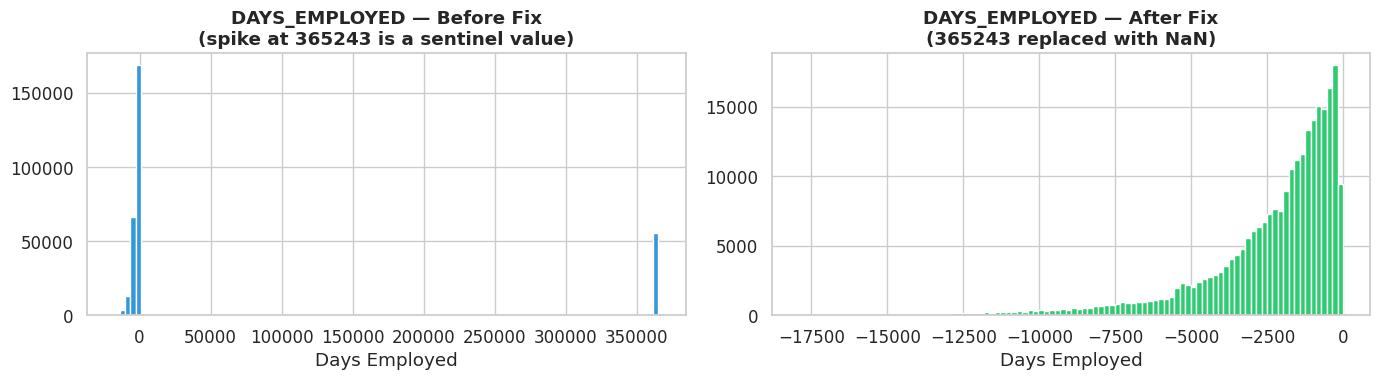


💡 Real-World Note: Sentinel values are extremely common in financial datasets.
   They come from legacy database systems using magic numbers instead of NULL.
   Always verify with domain experts before replacing them.


In [8]:
# ── Anomaly 1: DAYS_EMPLOYED sentinel value ────────────────────────────────
print('=== DAYS_EMPLOYED Anomaly ===')
sentinel_mask = train['DAYS_EMPLOYED'] == 365243
print(f'Rows with DAYS_EMPLOYED = 365243 : {sentinel_mask.sum():,} ({sentinel_mask.mean()*100:.1f}%)')
print(f'Default rate in sentinel group   : {train.loc[sentinel_mask, "TARGET"].mean()*100:.2f}%')
print(f'Default rate in normal group     : {train.loc[~sentinel_mask, "TARGET"].mean()*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Before fix
axes[0].hist(train['DAYS_EMPLOYED'], bins=100, color='#3498db', edgecolor='white')
axes[0].set_title('DAYS_EMPLOYED — Before Fix\n(spike at 365243 is a sentinel value)', fontweight='bold')
axes[0].set_xlabel('Days Employed')
# After fix
clean = train['DAYS_EMPLOYED'].replace(365243, np.nan)
axes[1].hist(clean.dropna(), bins=100, color='#2ecc71', edgecolor='white')
axes[1].set_title('DAYS_EMPLOYED — After Fix\n(365243 replaced with NaN)', fontweight='bold')
axes[1].set_xlabel('Days Employed')
plt.tight_layout()
plt.show()

print('\n💡 Real-World Note: Sentinel values are extremely common in financial datasets.')
print('   They come from legacy database systems using magic numbers instead of NULL.')
print('   Always verify with domain experts before replacing them.')

In [9]:
# ── Anomaly 2: DAYS_BIRTH, DAYS_REGISTRATION, DAYS_ID_PUBLISH ─────────────
# These are negative (days before application date). Convert to years for interpretability.
print('=== DAYS_ Columns — Negative Values (Expected) ===')
days_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH']
print('These are stored as negative integers (days relative to application date).')
print('Min values (most negative = oldest):')
print(train[days_cols].min())
print('\n→ We will convert these to positive years in the preprocessing pipeline.')

=== DAYS_ Columns — Negative Values (Expected) ===
These are stored as negative integers (days relative to application date).
Min values (most negative = oldest):
DAYS_BIRTH          -25229.0
DAYS_EMPLOYED       -17912.0
DAYS_REGISTRATION   -24672.0
DAYS_ID_PUBLISH      -7197.0
dtype: float64

→ We will convert these to positive years in the preprocessing pipeline.


In [10]:
# ── Anomaly 3: CODE_GENDER ─────────────────────────────────────────────────
print('=== CODE_GENDER Anomaly ===')
print(train['CODE_GENDER'].value_counts())
print('\n→ "XNA" is a sentinel for unknown/not applicable. Treat as NaN or separate category.')

=== CODE_GENDER Anomaly ===
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

→ "XNA" is a sentinel for unknown/not applicable. Treat as NaN or separate category.


## 1.5 — EXT_SOURCE Deep Dive (Your Strongest Predictors)

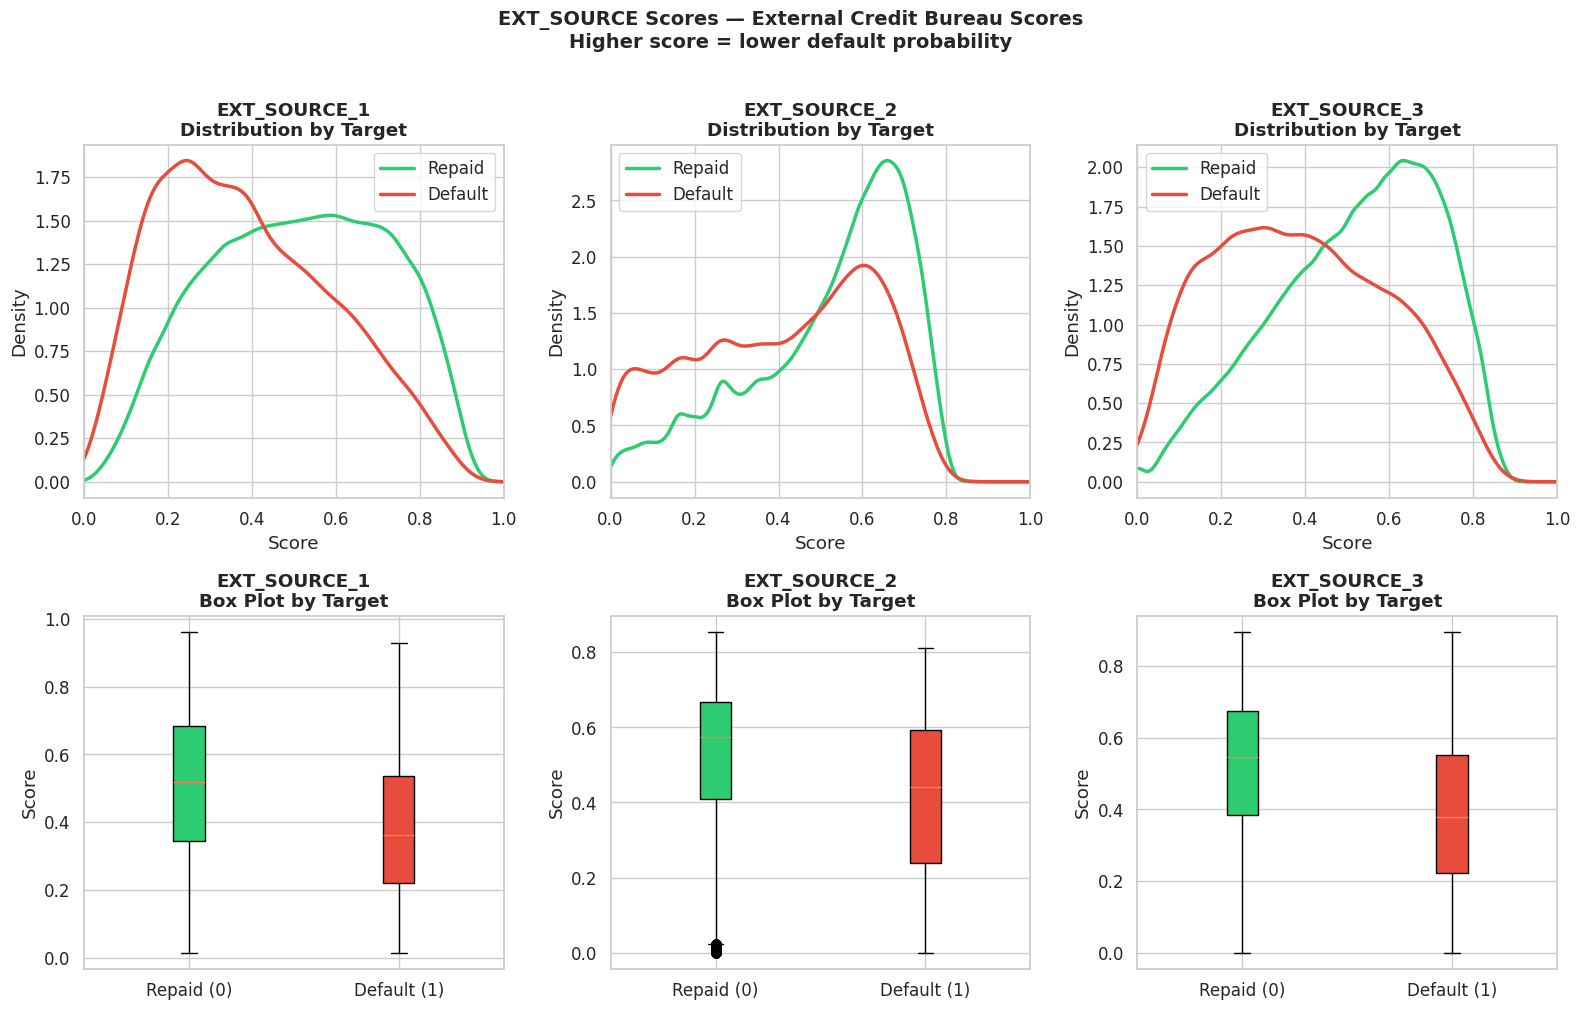

Correlation with TARGET:
  EXT_SOURCE_1: -0.1553
  EXT_SOURCE_2: -0.1605
  EXT_SOURCE_3: -0.1789

💡 EXT_SOURCE features are external credit scores from 3rd-party bureaus.
   They will be the most important features in your baseline model.
   In Phase 3, we will create interaction features between them.


In [11]:
ext_sources = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(ext_sources):
    # KDE by target
    ax = axes[0, i]
    for target_val, label, color in [(0, 'Repaid', PALETTE['repaid']),
                                      (1, 'Default', PALETTE['default'])]:
        subset = train.loc[train['TARGET'] == target_val, col].dropna()
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2.5)
    ax.set_title(f'{col}\nDistribution by Target', fontweight='bold')
    ax.set_xlabel('Score')
    ax.legend()
    ax.set_xlim(0, 1)

    # Box plot by target
    ax2 = axes[1, i]
    data_box = [train.loc[train['TARGET'] == 0, col].dropna(),
                train.loc[train['TARGET'] == 1, col].dropna()]
    bp = ax2.boxplot(data_box, patch_artist=True,
                     labels=['Repaid (0)', 'Default (1)'])
    bp['boxes'][0].set_facecolor(PALETTE['repaid'])
    bp['boxes'][1].set_facecolor(PALETTE['default'])
    ax2.set_title(f'{col}\nBox Plot by Target', fontweight='bold')
    ax2.set_ylabel('Score')

plt.suptitle('EXT_SOURCE Scores — External Credit Bureau Scores\n'
             'Higher score = lower default probability', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlation with target
print('Correlation with TARGET:')
for col in ext_sources:
    corr = train[col].corr(train['TARGET'])
    print(f'  {col}: {corr:.4f}')
print('\n💡 EXT_SOURCE features are external credit scores from 3rd-party bureaus.')
print('   They will be the most important features in your baseline model.')
print('   In Phase 3, we will create interaction features between them.')

## 1.6 — Numerical Features vs Target

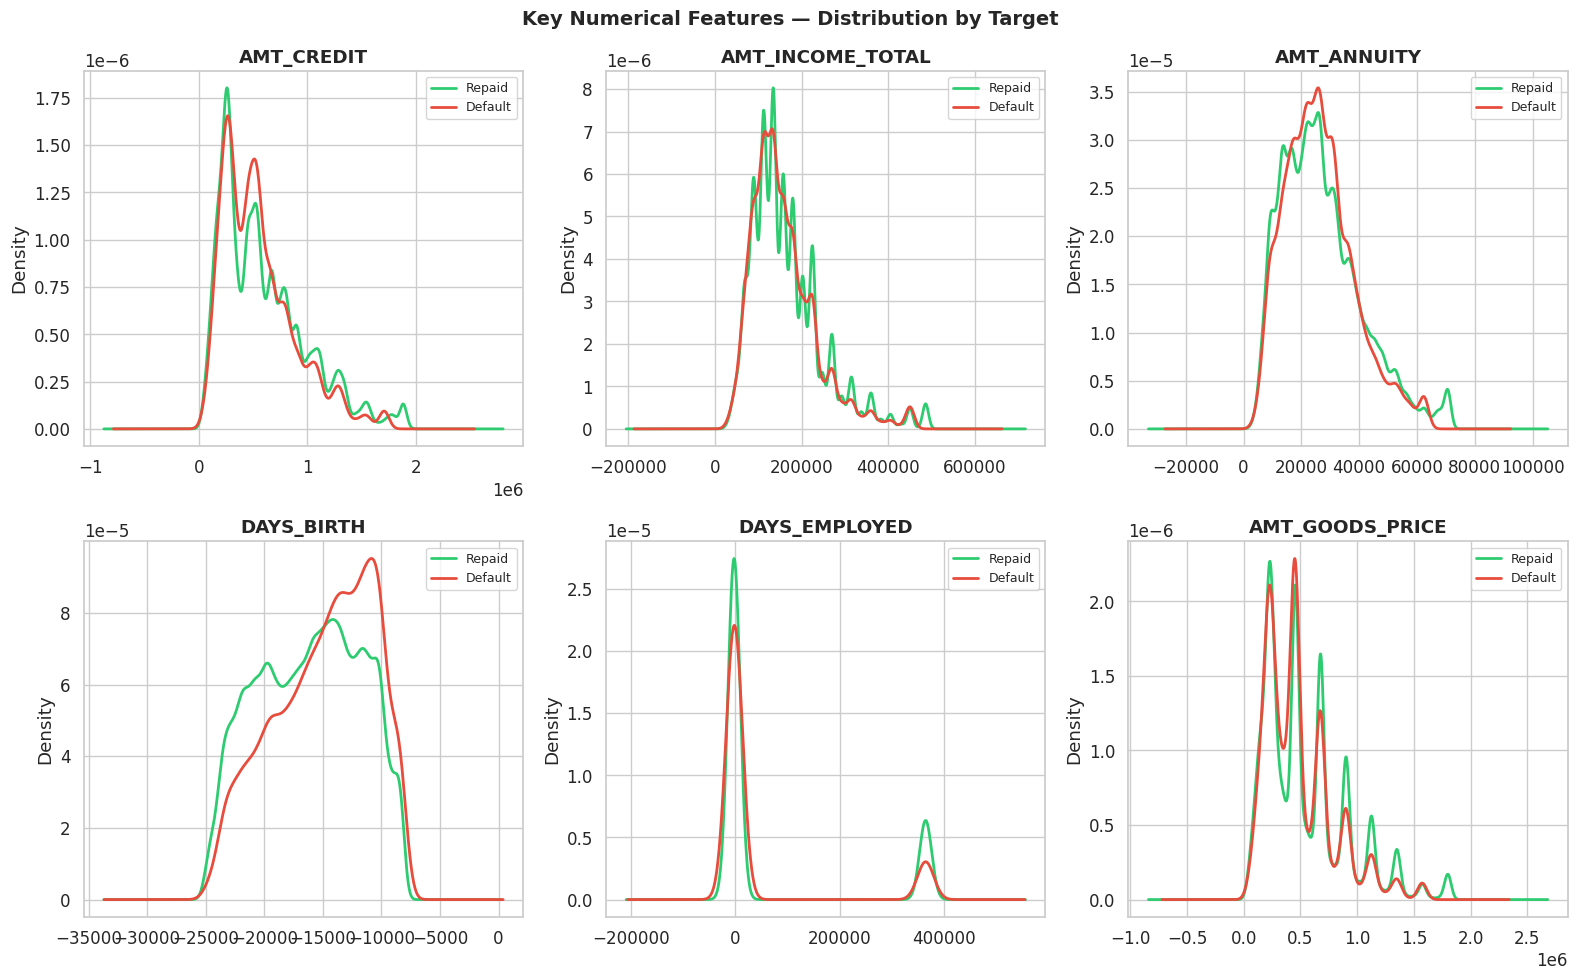

In [12]:
# Key numerical features to analyze
key_num = [
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_GOODS_PRICE'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    ax = axes[i]
    for target_val, label, color in [(0, 'Repaid', PALETTE['repaid']),
                                      (1, 'Default', PALETTE['default'])]:
        subset = train.loc[train['TARGET'] == target_val, col].dropna()
        # Cap outliers at 99th percentile for cleaner plots
        cap = subset.quantile(0.99)
        subset = subset.clip(upper=cap)
        subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Key Numerical Features — Distribution by Target', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.7 — Categorical Features vs Target (Default Rate per Category)

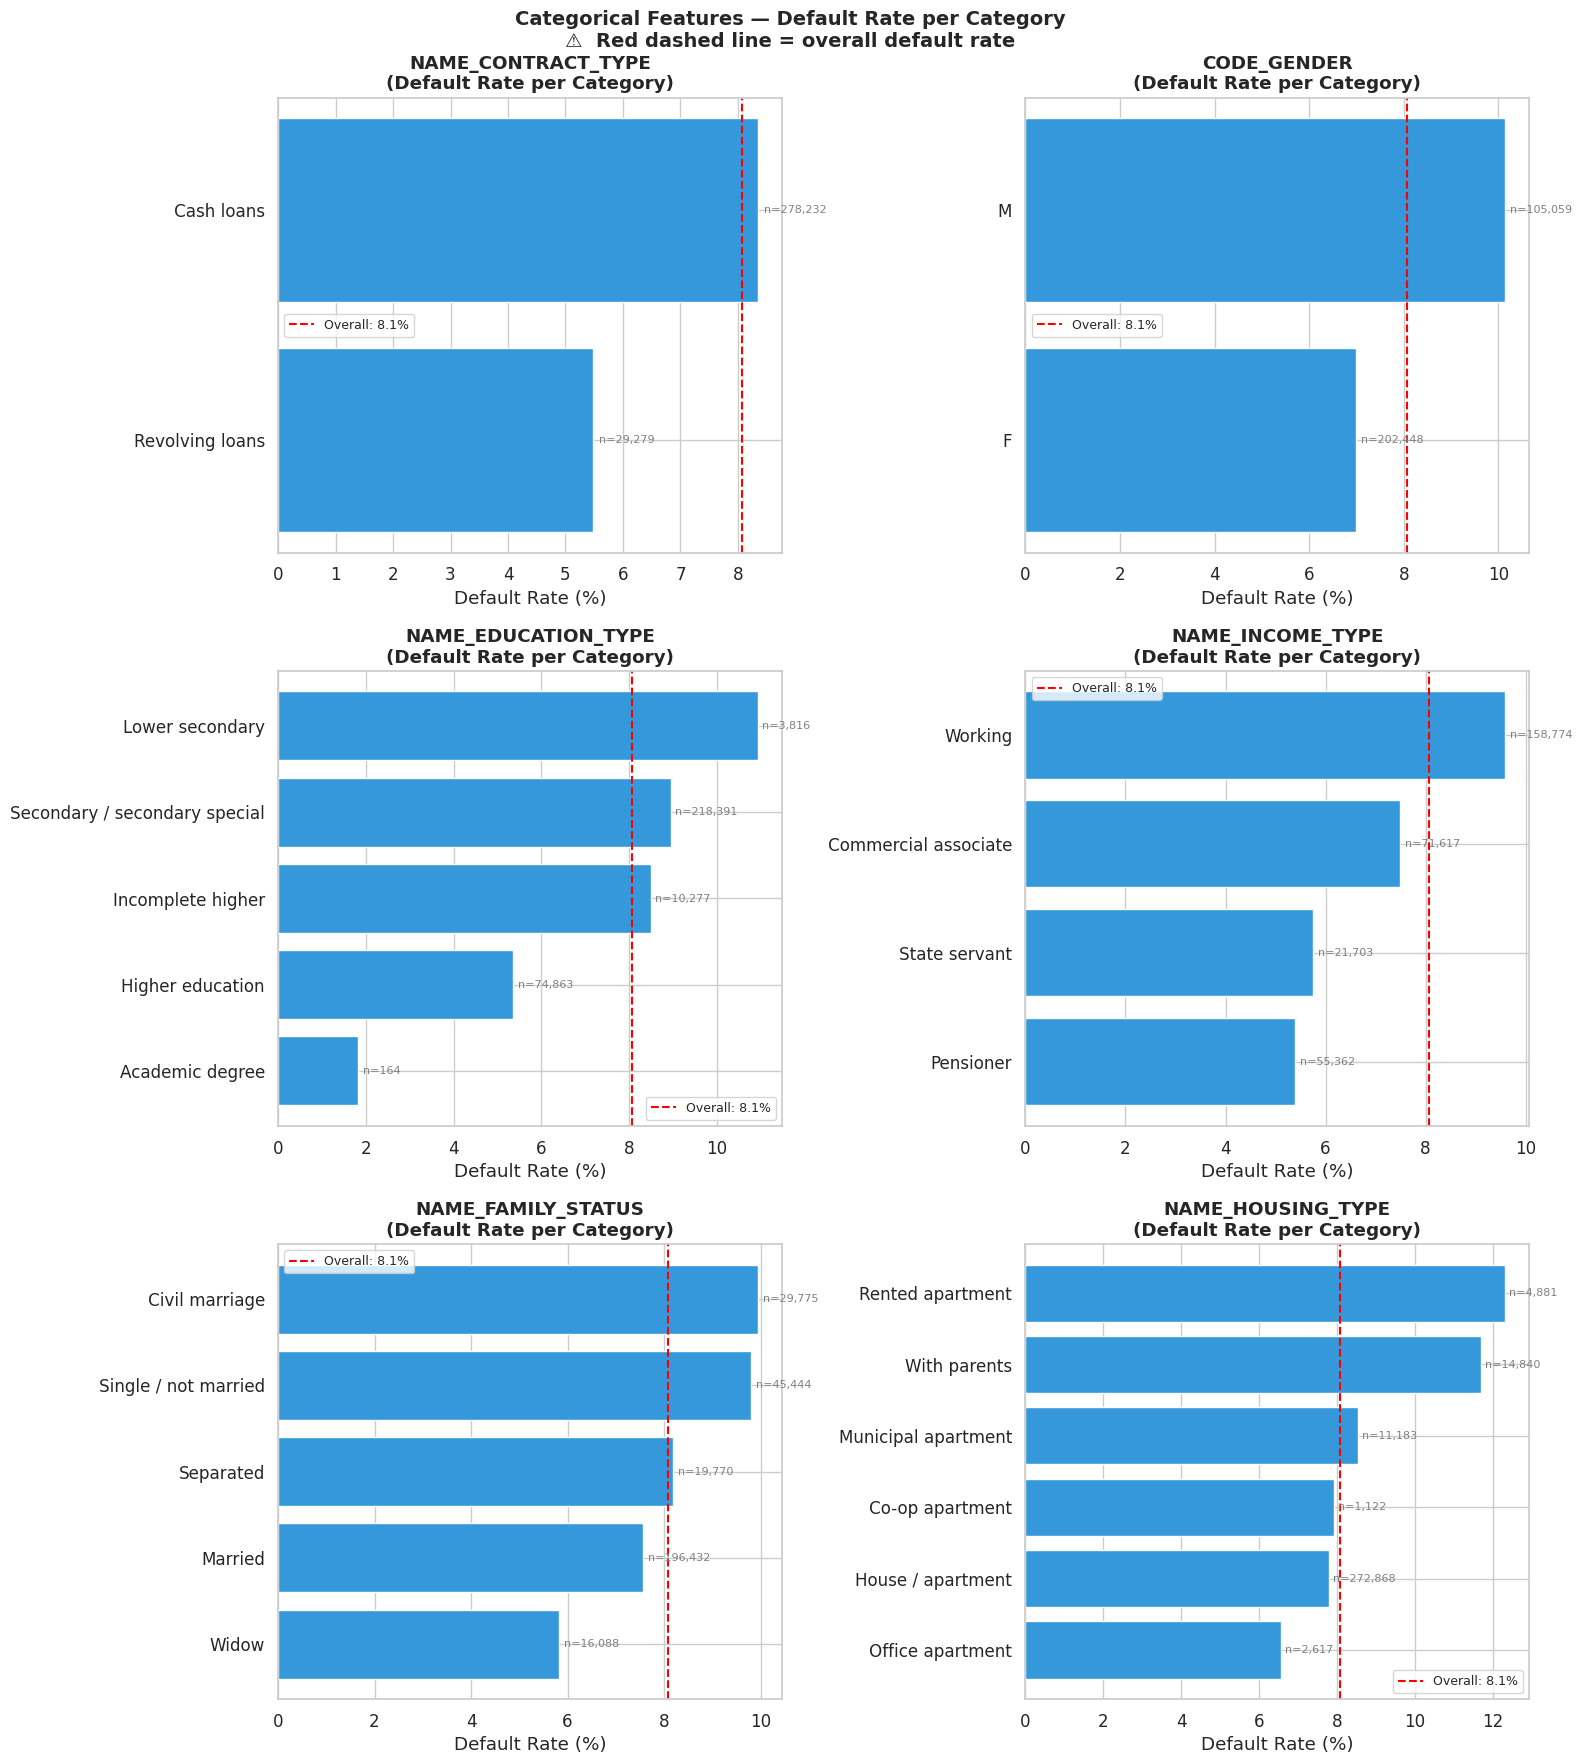

💡 Real-World Note (Fair Lending):
   Features like CODE_GENDER, NAME_EDUCATION_TYPE, NAME_INCOME_TYPE
   can be proxies for protected classes under fair lending regulations.
   In production, using them requires legal review and bias testing.
   We use them here for learning purposes.


In [13]:
def plot_categorical_vs_target(df, col, ax, min_count=100):
    """Plot default rate per category, sorted by default rate."""
    stats = df.groupby(col)['TARGET'].agg(['mean', 'count']).reset_index()
    stats.columns = [col, 'default_rate', 'count']
    stats = stats[stats['count'] >= min_count]  # Remove rare categories
    stats = stats.sort_values('default_rate', ascending=True)
    stats['default_rate_pct'] = stats['default_rate'] * 100

    bars = ax.barh(stats[col].astype(str), stats['default_rate_pct'],
                   color='#3498db', edgecolor='white')
    # Overall default rate line
    overall = df['TARGET'].mean() * 100
    ax.axvline(overall, color='red', linestyle='--', linewidth=1.5,
               label=f'Overall: {overall:.1f}%')
    ax.set_xlabel('Default Rate (%)')
    ax.set_title(f'{col}\n(Default Rate per Category)', fontweight='bold')
    ax.legend(fontsize=9)
    # Add count labels
    for bar, cnt in zip(bars, stats['count']):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'n={cnt:,}', va='center', fontsize=8, color='gray')

key_cat = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
           'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(key_cat):
    plot_categorical_vs_target(train, col, axes[i])

plt.suptitle('Categorical Features — Default Rate per Category\n'
             '⚠️  Red dashed line = overall default rate', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Real-World Note (Fair Lending):')
print('   Features like CODE_GENDER, NAME_EDUCATION_TYPE, NAME_INCOME_TYPE')
print('   can be proxies for protected classes under fair lending regulations.')
print('   In production, using them requires legal review and bias testing.')
print('   We use them here for learning purposes.')

## 1.8 — Correlation Heatmap

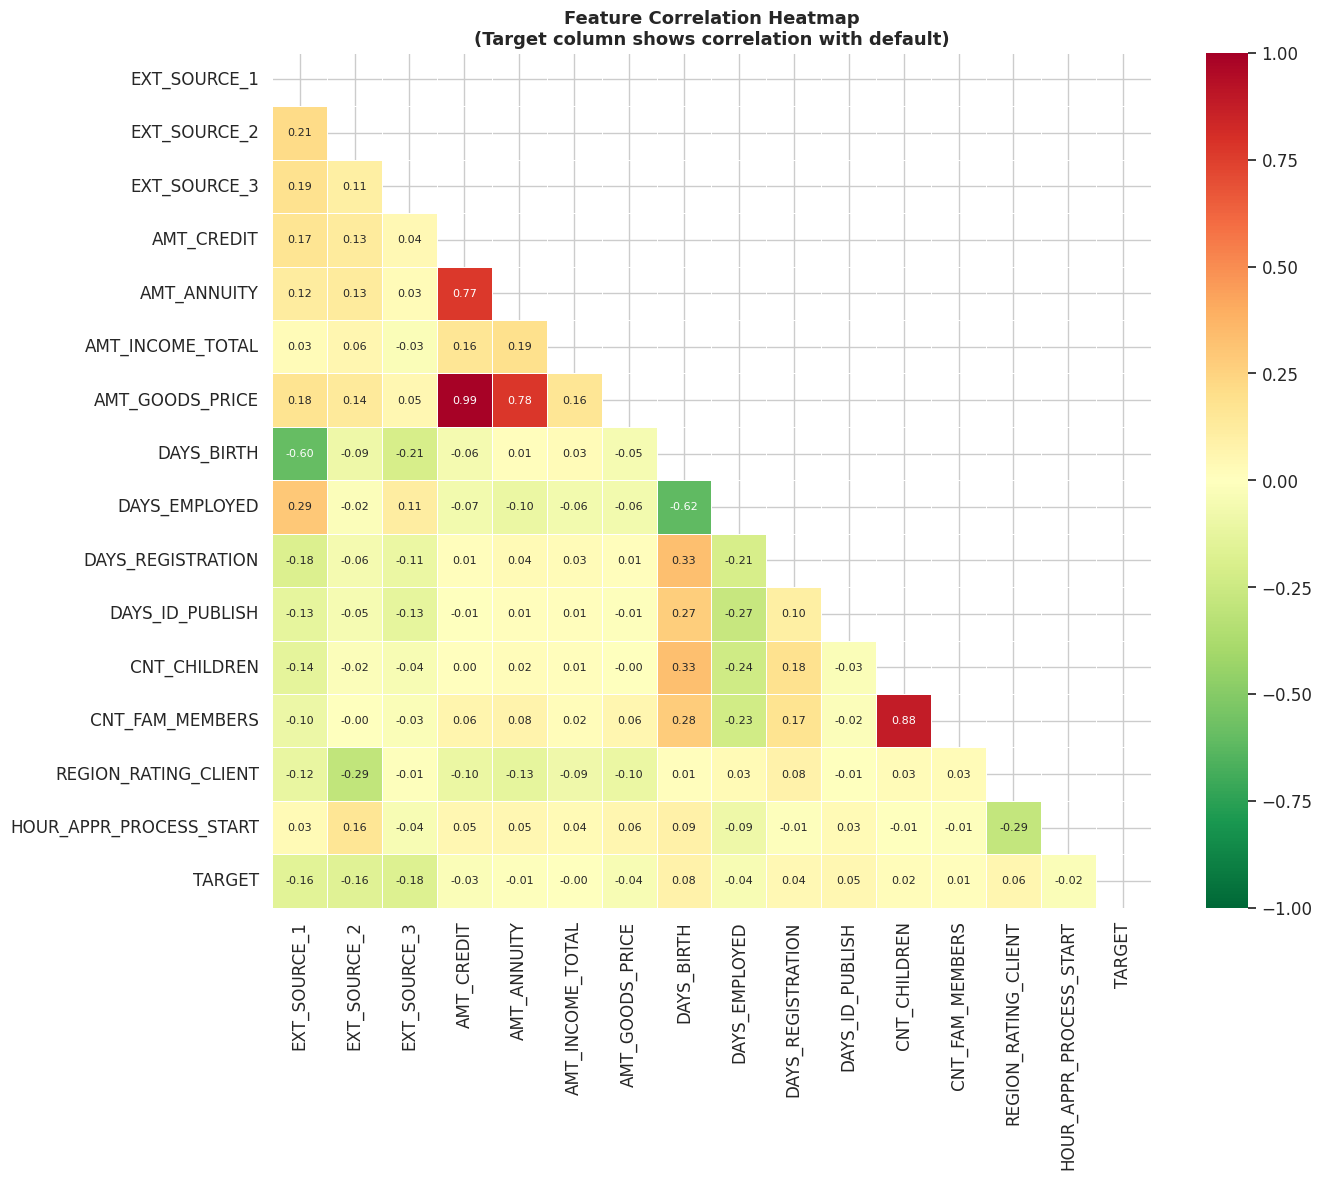

Top correlations with TARGET (absolute value):
EXT_SOURCE_3            0.178919
EXT_SOURCE_2            0.160472
EXT_SOURCE_1            0.155317
DAYS_BIRTH              0.078239
REGION_RATING_CLIENT    0.058899
DAYS_ID_PUBLISH         0.051457
DAYS_EMPLOYED           0.044932
DAYS_REGISTRATION       0.041975
AMT_GOODS_PRICE         0.039645
AMT_CREDIT              0.030369


In [14]:
# Select numeric features with meaningful correlation to target
corr_cols = ext_sources + [
    'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
    'HOUR_APPR_PROCESS_START', 'TARGET'
]
corr_cols = [c for c in corr_cols if c in train.columns]

corr_matrix = train[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap\n(Target column shows correlation with default)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with TARGET
print('Top correlations with TARGET (absolute value):')
target_corr = corr_matrix['TARGET'].drop('TARGET').abs().sort_values(ascending=False)
print(target_corr.head(10).to_string())

## 1.9 — Phase 1 Summary & Findings Log

> **Discipline:** Every finding gets documented. This is your audit trail.

```
FINDINGS LOG — Phase 1
══════════════════════════════════════════════════════════════════

[IMBALANCE]
  - 8% default rate. Use stratified CV. Never report accuracy.

[STRONGEST FEATURES]
  - EXT_SOURCE_1/2/3 are the best individual predictors (external credit scores)
  - DAYS_BIRTH (age) shows clear negative correlation with default
  - DAYS_EMPLOYED, AMT_CREDIT, AMT_ANNUITY all show separation

[ANOMALIES TO FIX]
  - DAYS_EMPLOYED = 365243 → replace with NaN (sentinel for unemployed/retired)
  - CODE_GENDER = 'XNA' → replace with NaN
  - DAYS_BIRTH is negative → convert to positive years

[MISSING VALUES]
  - EXT_SOURCE_1: ~56% missing — HIGH PRIORITY, create is_missing indicator
  - EXT_SOURCE_3: ~19% missing — create is_missing indicator
  - OWN_CAR_AGE: ~66% missing — likely means no car (business logic imputation)
  - OCCUPATION_TYPE: ~31% missing — could mean unemployed

[FAIRNESS FLAGS]
  - CODE_GENDER, NAME_EDUCATION_TYPE, REGION_* → sensitive proxies
  - Require legal review before production use

[PHASE 3 HYPOTHESES]
  - AMT_CREDIT / AMT_INCOME_TOTAL ratio will outperform either alone
  - EXT_SOURCE mean/product interaction will be powerful
  - Age + employment stability combo signal is strong
  - Missing EXT_SOURCE_1 is itself a default risk signal
══════════════════════════════════════════════════════════════════
```

---
# ⚙️ PHASE 2 — Baseline Model with Pipeline
---

> **Rule:** Do the minimum necessary to make the model run. No clever tricks yet.
> This score is the north star. Every future experiment must beat it.

## 2.1 — Custom Transformers

In [15]:
class AnomalyFixer(BaseEstimator, TransformerMixin):
    """
    Fixes known data anomalies before any modeling.
    
    Fixes applied:
    - DAYS_EMPLOYED = 365243 → NaN  (sentinel for unemployed/retired)
    - CODE_GENDER = 'XNA'    → NaN  (unknown gender sentinel)
    
    Real-world note: In production, these rules are documented in a
    'data quality register' and versioned alongside the model.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        if 'DAYS_EMPLOYED' in X.columns:
            X['DAYS_EMPLOYED'] = X['DAYS_EMPLOYED'].replace(365243, np.nan)
        if 'CODE_GENDER' in X.columns:
            X['CODE_GENDER'] = X['CODE_GENDER'].replace('XNA', np.nan)
        return X


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """
    Ordinal-encodes all object columns. LightGBM handles the rest.
    
    Why not OneHotEncoder here?
    - Would create 100+ columns from ORGANIZATION_TYPE alone
    - LightGBM with categorical dtype handles this more efficiently
    - OHE is better suited for linear models (Phase 4)
    """
    def __init__(self):
        self.encoder = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            encoded_missing_value=-2
        )
        self.cat_cols_ = []

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include='object').columns.tolist()
        if self.cat_cols_:
            self.encoder.fit(X[self.cat_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        if self.cat_cols_:
            X[self.cat_cols_] = self.encoder.transform(X[self.cat_cols_])
        return X


class DropIDColumns(BaseEstimator, TransformerMixin):
    """
    Removes ID columns that carry no predictive information.
    Keeping IDs can cause leakage in some model types.
    """
    def __init__(self, id_cols=None):
        self.id_cols = id_cols or ['SK_ID_CURR']

    def fit(self, X, y=None):
        self.cols_to_drop_ = [c for c in self.id_cols if c in X.columns]
        return self

    def transform(self, X):
        return X.drop(columns=self.cols_to_drop_, errors='ignore')


print('✅ Custom transformers defined')

✅ Custom transformers defined


## 2.2 — Build the Preprocessing Pipeline

In [16]:
# ── Preprocessing Pipeline ────────────────────────────────────────────────────
#
# Step 1 → Drop ID columns (no predictive value)
# Step 2 → Fix known data anomalies (sentinel values)
# Step 3 → Encode categorical columns
#
# NOTE: We deliberately DO NOT impute here.
# LightGBM handles NaN natively — imputing now would hide the missing signal.
# We will experiment with imputation strategies in Phase 3.

preprocessing_pipeline = Pipeline(steps=[
    ('drop_ids',    DropIDColumns(id_cols=['SK_ID_CURR'])),
    ('fix_anomaly', AnomalyFixer()),
    ('encode_cats', CategoricalEncoder()),
])

print('Preprocessing Pipeline:')
print(preprocessing_pipeline)
print('\n💡 No imputation in baseline — LightGBM handles NaN natively.')
print('   This is a deliberate choice, not an oversight.')

Preprocessing Pipeline:
Pipeline(steps=[('drop_ids', DropIDColumns(id_cols=['SK_ID_CURR'])),
                ('fix_anomaly', AnomalyFixer()),
                ('encode_cats', CategoricalEncoder())])

💡 No imputation in baseline — LightGBM handles NaN natively.
   This is a deliberate choice, not an oversight.


## 2.3 — Prepare Data

In [17]:
# Separate features and target
X = train.drop(columns=['TARGET'])
y = train['TARGET']
X_test = test.copy()

# Apply preprocessing
X_processed      = preprocessing_pipeline.fit_transform(X)
X_test_processed = preprocessing_pipeline.transform(X_test)

print(f'X_processed shape : {X_processed.shape}')
print(f'X_test shape      : {X_test_processed.shape}')
print(f'Target distribution:\n{y.value_counts(normalize=True).mul(100).round(2)}')

X_processed shape : (307511, 120)
X_test shape      : (48744, 120)
Target distribution:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


## 2.4 — LightGBM Baseline with Stratified K-Fold

In [18]:
# ── Baseline LightGBM Parameters ─────────────────────────────────────────────
#
# Philosophy: Conservative, safe, reproducible.
# - NOT default params (those can overfit)
# - NOT tuned params (that comes in Phase 4)
# - Just solid, well-reasoned starting values

BASELINE_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'boosting_type'    : 'gbdt',
    'n_estimators'     : 2000,          # High — early stopping will pick the right number
    'learning_rate'    : 0.05,          # Slow & stable
    'num_leaves'       : 31,            # Default — not too complex
    'min_child_samples': 20,            # Prevents overfitting on small leaves
    'subsample'        : 0.8,           # Row sampling — slight regularization
    'colsample_bytree' : 0.8,           # Feature sampling
    'reg_alpha'        : 0.0,           # L1 — no regularization in baseline
    'reg_lambda'       : 1.0,           # L2 — light regularization
    'n_jobs'           : -1,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1,
}

print('Baseline Parameters:')
for k, v in BASELINE_PARAMS.items():
    print(f'  {k:25s}: {v}')

Baseline Parameters:
  objective                : binary
  metric                   : auc
  boosting_type            : gbdt
  n_estimators             : 2000
  learning_rate            : 0.05
  num_leaves               : 31
  min_child_samples        : 20
  subsample                : 0.8
  colsample_bytree         : 0.8
  reg_alpha                : 0.0
  reg_lambda               : 1.0
  n_jobs                   : -1
  random_state             : 42
  verbose                  : -1


In [19]:
# ── Cross-Validation Training Loop ────────────────────────────────────────────

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Storage
oof_preds        = np.zeros(len(X_processed))   # Out-of-Fold predictions
test_preds       = np.zeros(len(X_test_processed))
fold_aucs        = []
fold_best_iters  = []
feature_importance_df = pd.DataFrame()

print(f'Training {N_FOLDS}-Fold Stratified CV Baseline...\n')
print(f'{"Fold":<6} {"Best Iter":<12} {"Val AUC":<12}')
print('─' * 32)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_processed, y), 1):
    X_train_fold = X_processed.iloc[train_idx] if hasattr(X_processed, 'iloc') else X_processed[train_idx]
    X_val_fold   = X_processed.iloc[val_idx]   if hasattr(X_processed, 'iloc') else X_processed[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold   = y.iloc[val_idx]

    model = lgb.LGBMClassifier(**BASELINE_PARAMS)

    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1)   # Suppress per-iteration output
        ]
    )

    # Predictions
    val_pred  = model.predict_proba(X_val_fold)[:, 1]
    test_pred = model.predict_proba(X_test_processed)[:, 1]

    oof_preds[val_idx] += val_pred
    test_preds          += test_pred / N_FOLDS

    fold_auc  = roc_auc_score(y_val_fold, val_pred)
    best_iter = model.best_iteration_
    fold_aucs.append(fold_auc)
    fold_best_iters.append(best_iter)

    print(f'{fold:<6} {best_iter:<12} {fold_auc:.6f}')

    # Feature importance
    fi = pd.DataFrame({
        'feature'    : X_processed.columns if hasattr(X_processed, 'columns') else [f'f{i}' for i in range(X_processed.shape[1])],
        'importance' : model.feature_importances_,
        'fold'       : fold
    })
    feature_importance_df = pd.concat([feature_importance_df, fi])

# ── Final Results ─────────────────────────────────────────────────────────────
oof_auc  = roc_auc_score(y, oof_preds)
mean_auc = np.mean(fold_aucs)
std_auc  = np.std(fold_aucs)

print('─' * 32)
print(f'\n📊 BASELINE RESULTS')
print(f'   OOF AUC        : {oof_auc:.6f}')
print(f'   Mean Fold AUC  : {mean_auc:.6f} ± {std_auc:.6f}')
print(f'   Avg Best Iter  : {np.mean(fold_best_iters):.0f} trees')
print(f'\n💡 This is your north star. Every future experiment must beat {oof_auc:.4f}')

Training 5-Fold Stratified CV Baseline...

Fold   Best Iter    Val AUC     
────────────────────────────────
1      740          0.756737
2      332          0.765235
3      393          0.757113
4      728          0.764776
5      561          0.756430
────────────────────────────────

📊 BASELINE RESULTS
   OOF AUC        : 0.760000
   Mean Fold AUC  : 0.760058 ± 0.004048
   Avg Best Iter  : 551 trees

💡 This is your north star. Every future experiment must beat 0.7600


## 2.5 — Additional Metrics

In [20]:
# Compute all metrics on OOF predictions
oof_auprc = average_precision_score(y, oof_preds)
oof_logloss = log_loss(y, oof_preds)
oof_gini = 2 * oof_auc - 1

print('📋 Full Metrics Report (OOF)')
print('=' * 40)
print(f'  AUC-ROC          : {oof_auc:.6f}')
print(f'  Gini Coefficient : {oof_gini:.6f}  ← Banking standard (2*AUC - 1)')
print(f'  AUC-PR           : {oof_auprc:.6f}  ← Better for imbalanced classes')
print(f'  Log Loss         : {oof_logloss:.6f}  ← Probability calibration quality')
print('=' * 40)
print('\n💡 Real-World Note:')
print('   Gini Coefficient is the standard metric in banking & credit scoring.')
print('   A Gini of 0.50 means AUC of 0.75 — industry calls this "good".')
print('   AUC-PR is more informative than AUC-ROC under class imbalance.')
print('   Log Loss measures probability calibration — critical for loan pricing.')

📋 Full Metrics Report (OOF)
  AUC-ROC          : 0.760000
  Gini Coefficient : 0.520000  ← Banking standard (2*AUC - 1)
  AUC-PR           : 0.243692  ← Better for imbalanced classes
  Log Loss         : 0.245721  ← Probability calibration quality

💡 Real-World Note:
   Gini Coefficient is the standard metric in banking & credit scoring.
   A Gini of 0.50 means AUC of 0.75 — industry calls this "good".
   AUC-PR is more informative than AUC-ROC under class imbalance.
   Log Loss measures probability calibration — critical for loan pricing.


## 2.6 — OOF Prediction Distribution

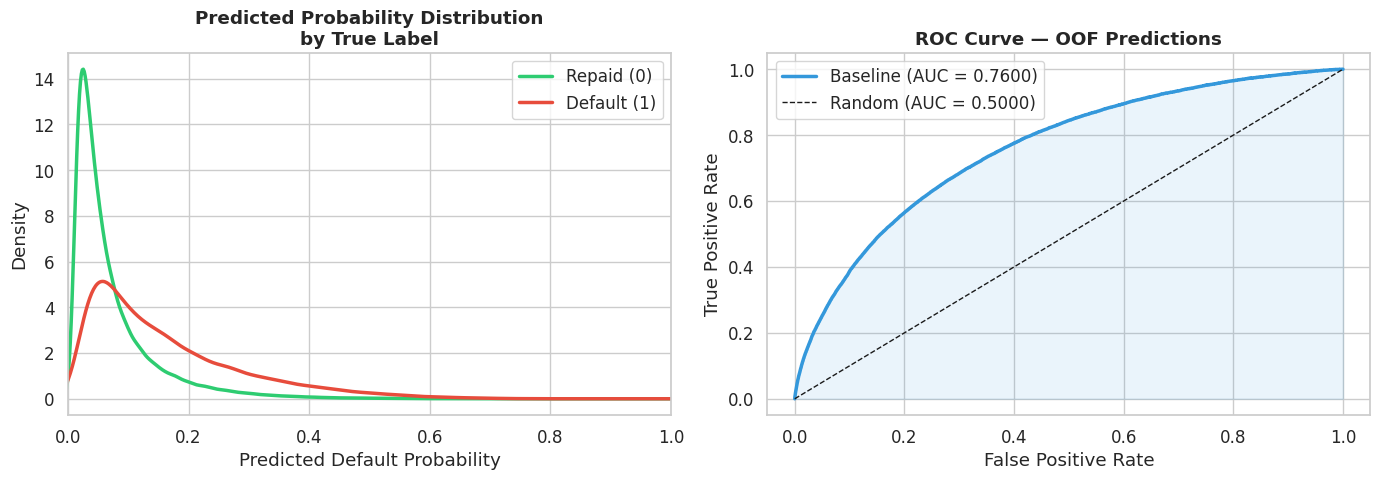

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of predicted probabilities by true label
ax = axes[0]
pd.Series(oof_preds[y == 0], name='Repaid (0)').plot.kde(ax=ax, color=PALETTE['repaid'], linewidth=2.5)
pd.Series(oof_preds[y == 1], name='Default (1)').plot.kde(ax=ax, color=PALETTE['default'], linewidth=2.5)
ax.set_title('Predicted Probability Distribution\nby True Label', fontweight='bold')
ax.set_xlabel('Predicted Default Probability')
ax.legend()
ax.set_xlim(0, 1)

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y, oof_preds)
ax2 = axes[1]
ax2.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'Baseline (AUC = {oof_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5000)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#3498db')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve — OOF Predictions', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 2.7 — Feature Importance

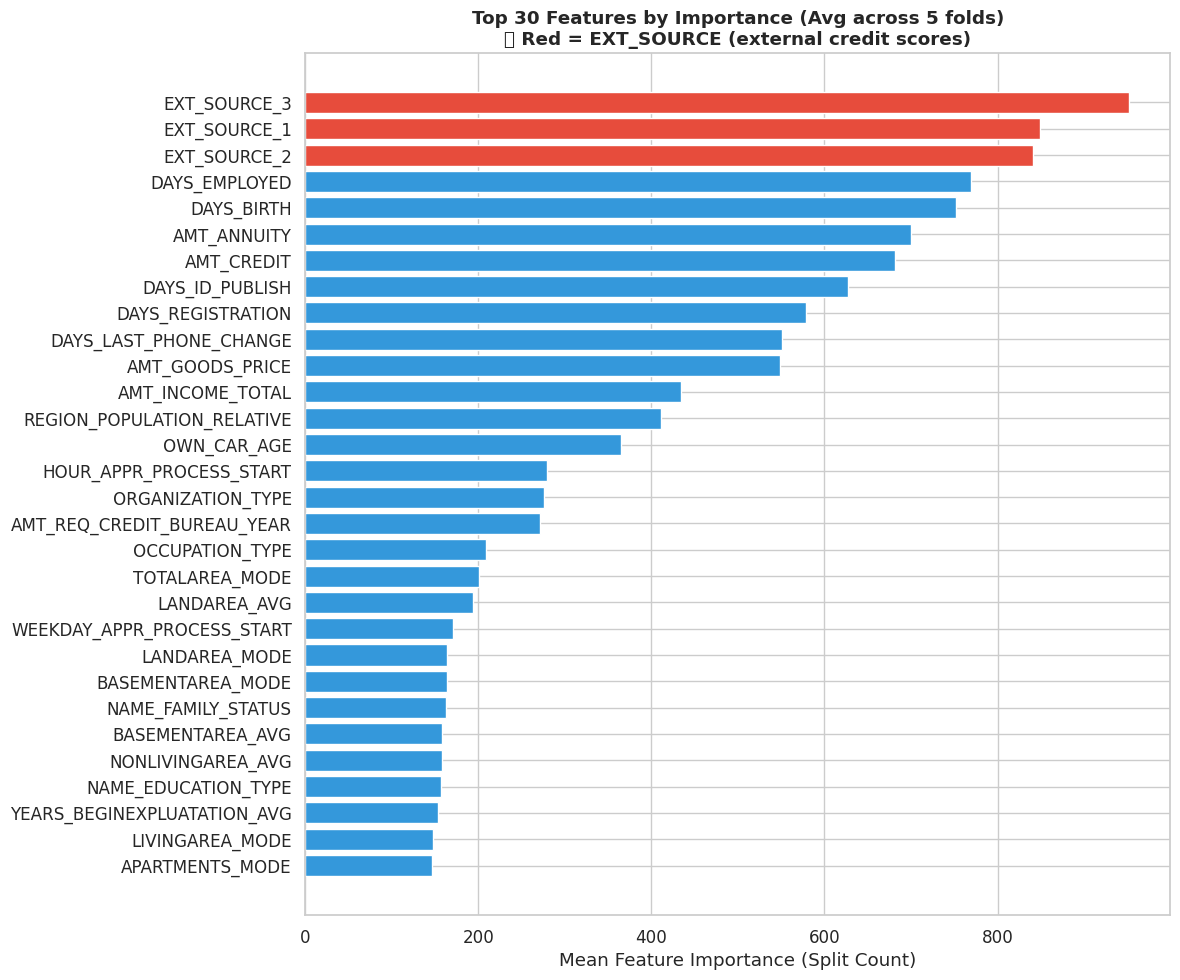


Features with ZERO importance: 7
['FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_20', 'FLAG_MOBIL', 'FLAG_DOCUMENT_7']
→ These are candidates for removal in Phase 3.

💡 Note: Use SHAP values for production feature importance.
   Split-based importance is biased toward high-cardinality features.


In [22]:
# Average importance across all folds
mean_importance = (
    feature_importance_df
    .groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
)

top_n = 30
top_features = mean_importance.head(top_n)

fig, ax = plt.subplots(figsize=(12, 10))
colors_imp = ['#e74c3c' if f.startswith('EXT_SOURCE') else '#3498db' 
              for f in top_features.index]
ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors_imp[::-1])
ax.set_title(f'Top {top_n} Features by Importance (Avg across {N_FOLDS} folds)\n'
             f'🔴 Red = EXT_SOURCE (external credit scores)', fontweight='bold')
ax.set_xlabel('Mean Feature Importance (Split Count)')
plt.tight_layout()
plt.show()

# Zero importance features — candidates for dropping
zero_imp = mean_importance[mean_importance == 0]
print(f'\nFeatures with ZERO importance: {len(zero_imp)}')
if len(zero_imp) > 0:
    print(zero_imp.index.tolist())
    print('→ These are candidates for removal in Phase 3.')

print('\n💡 Note: Use SHAP values for production feature importance.')
print('   Split-based importance is biased toward high-cardinality features.')

## 2.8 — Experiment Tracker

In [23]:
# ── Experiment Tracking Table ─────────────────────────────────────────────────
# In production: use MLflow, W&B, or Neptune.
# Here: a simple DataFrame that grows with each experiment.
# DISCIPLINE: Never delete rows. Every experiment is recorded.

experiment_log = pd.DataFrame([{
    'experiment_id'  : '01_baseline',
    'description'    : 'Baseline — application_train only, no FE',
    'tables_used'    : 'application_train',
    'feature_count'  : X_processed.shape[1],
    'preprocessing'  : 'fix_anomalies + label_encode',
    'model'          : 'LightGBM',
    'n_folds'        : N_FOLDS,
    'oof_auc'        : round(oof_auc, 6),
    'mean_fold_auc'  : round(mean_auc, 6),
    'std_fold_auc'   : round(std_auc, 6),
    'gini'           : round(oof_gini, 6),
    'auc_pr'         : round(oof_auprc, 6),
    'log_loss'       : round(oof_logloss, 6),
    'avg_best_iter'  : round(np.mean(fold_best_iters), 0),
    'notes'          : 'LOCKED BASELINE — do not modify'
}])

print('📋 Experiment Log:')
experiment_log.T.style.set_properties(**{'text-align': 'left'})

📋 Experiment Log:


,0
experiment_id,01_baseline
description,"Baseline — application_train only, no FE"
tables_used,application_train
feature_count,120
preprocessing,fix_anomalies + label_encode
model,LightGBM
n_folds,5
oof_auc,0.760000
mean_fold_auc,0.760058
std_fold_auc,0.004048


## 2.9 — Generate Submission File

In [24]:
submission = pd.DataFrame({
    'SK_ID_CURR' : test['SK_ID_CURR'],
    'TARGET'     : test_preds
})

submission.to_csv('submission_baseline.csv', index=False)

print('✅ Submission saved: submission_baseline.csv')
print(f'   Shape: {submission.shape}')
print(f'   Predicted default prob range: [{test_preds.min():.4f}, {test_preds.max():.4f}]')
print(f'   Mean predicted default prob  : {test_preds.mean():.4f}')
submission.head()

✅ Submission saved: submission_baseline.csv
   Shape: (48744, 2)
   Predicted default prob range: [0.0040, 0.7363]
   Mean predicted default prob  : 0.0788


,SK_ID_CURR,TARGET
0,100001,0.031433
1,100005,0.118384
2,100013,0.015580
3,100028,0.035359
4,100038,0.137127


---
## ✅ Phase 1 & 2 Complete

| | Result |
|---|---|
| **Baseline OOF AUC** | *see above* |
| **Pipeline** | AnomalyFixer → CategoricalEncoder → LightGBM |
| **Validation** | 5-Fold Stratified CV |
| **Next step** | Phase 3 — Feature Engineering from all 7 tables |

### What's Coming in Phase 3:
- Engineer ratio features from `application_train` (credit/income, annuity/credit, etc.)
- Aggregate all 6 supplementary tables into statistical features
- Create `is_missing` indicator features for high-signal nulls
- Target encoding for high-cardinality categoricals
- Expected AUC improvement: **+0.02 to +0.04**

---
> 💡 **Real-World Mindset Reminder:**  
> The pipeline you built here is production-ready in structure. In a real ML system,
> this pipeline would be serialized with `joblib`, versioned in a model registry,
> and refit on new data monthly. The discipline of separating preprocessing from
> modeling is what prevents data leakage in production.

In [25]:
def reduce_memory(df, verbose=True):
    """
    Downcast numeric columns to smallest valid dtype.
    Typically cuts memory by 40-60%.
    
    Real-world note: Always do this on load in Kaggle kernels.
    The full dataset can exceed 10GB without downcasting.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1e6
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1e6
    if verbose:
        print(f'  Memory: {start_mem:.1f} MB → {end_mem:.1f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df


def run_cv(X, y, params, n_folds=5, label='experiment'):
    """
    Reusable 5-fold stratified CV runner.
    Returns OOF predictions, OOF AUC, fold AUCs.
    
    Use this after EVERY feature group addition.
    Record the result in experiment_log before moving on.
    """
    skf       = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds = np.zeros(len(X))
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  [{label}] OOF AUC: {oof_auc:.6f} | '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return oof_preds, oof_auc, fold_aucs


# Shared LightGBM params — same as Phase 2 baseline
LGB_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_lambda'       : 1.0,
    'n_jobs'           : -1,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1,
}

print('✅ Utilities defined')

✅ Utilities defined


In [26]:
print('Loading data...')
train = pd.read_csv(DATA_PATH + 'application_train.csv')
test  = pd.read_csv(DATA_PATH + 'application_test.csv')
print(f'  Train: {train.shape} | Test: {test.shape}')

train = reduce_memory(train)
test  = reduce_memory(test)

# ── Fix known anomalies ───────────────────────────────────────────────────────
# DAYS_EMPLOYED = 365243 → sentinel for unemployed/retired
for df in [train, test]:
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    df['CODE_GENDER']   = df['CODE_GENDER'].replace('XNA', np.nan)

y = train['TARGET'].copy()
print(f'\nTarget distribution: {y.value_counts(normalize=True).mul(100).round(1).to_dict()}')

Loading data...
  Train: (307511, 122) | Test: (48744, 121)
  Memory: 529.5 MB → 363.8 MB (31.3% reduction)
  Memory: 83.6 MB → 57.6 MB (31.0% reduction)

Target distribution: {0: 91.9, 1: 8.1}


In [27]:
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Ordinal-encode all object columns. Safe for train/test."""
    def __init__(self):
        self.encoder  = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            encoded_missing_value=-2
        )
        self.cat_cols_ = []

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include='object').columns.tolist()
        if self.cat_cols_:
            self.encoder.fit(X[self.cat_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        if self.cat_cols_:
            X[self.cat_cols_] = self.encoder.transform(X[self.cat_cols_])
        return X


base_pipeline = Pipeline([
    ('encode_cats', CategoricalEncoder()),
])

print('✅ Preprocessing pipeline ready')

✅ Preprocessing pipeline ready


In [28]:
def add_credit_income_ratios(df):
    """
    Ratio features derived from credit, income, and annuity amounts.

    Why ratios beat raw values:
      A $50K loan means something very different for someone earning $30K
      vs. $300K. The ratio captures the relative burden.
      
    These mirror what loan officers compute manually (debt-to-income ratio
    is a legally recognized underwriting criterion in most countries).
    """
    df = df.copy()

    # How large is the loan relative to annual income?
    df['CREDIT_INCOME_RATIO']    = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

    # Monthly payment burden as % of income
    df['ANNUITY_INCOME_RATIO']   = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

    # How quickly are they repaying? (higher = faster)
    df['CREDIT_TERM']            = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

    # Loan-to-value ratio — how much extra are they borrowing beyond goods price?
    df['GOODS_CREDIT_RATIO']     = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)

    # Income per family member — family financial pressure
    df['INCOME_PER_PERSON']      = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

    # Loan amount per family member
    df['CREDIT_PER_PERSON']      = df['AMT_CREDIT'] / (df['CNT_FAM_MEMBERS'] + 1)

    # Down payment proxy — difference between goods price and credit
    df['AMT_DOWN_PAYMENT_PROXY'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

    return df


print('✅ Credit/income ratio functions defined')

# Preview new features
sample = add_credit_income_ratios(train.head())
new_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
            'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON', 'CREDIT_PER_PERSON',
            'AMT_DOWN_PAYMENT_PROXY']
sample[new_cols]

✅ Credit/income ratio functions defined


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,GOODS_CREDIT_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,AMT_DOWN_PAYMENT_PROXY
0,2.007879,0.121977,0.060749,0.863259,101250.0,203298.75,-55597.5
1,4.790732,0.132216,0.027598,0.873210,90000.0,431167.50,-164002.5
2,1.999970,0.099999,0.050000,0.999993,33750.0,67500.00,0.0
3,2.316149,0.219898,0.094941,0.949842,45000.0,104227.50,-15682.5
4,4.222188,0.179961,0.042623,0.999998,60750.0,256500.00,0.0


In [29]:
def add_age_employment_features(df):
    """
    Time-based features from DAYS_ columns.

    DAYS_* are stored as negative integers (days before application).
    We convert to positive years for interpretability and create
    interaction features that capture employment stability.

    Real-world insight:
      A 25-year-old employed for 3 years is very different from a
      50-year-old employed for 3 years. The ratio captures this.
    """
    df = df.copy()

    # Convert days to years (positive)
    df['AGE_YEARS']               = df['DAYS_BIRTH']        / -365
    df['EMPLOYED_YEARS']          = df['DAYS_EMPLOYED']     / -365   # NaN for unemployed
    df['REGISTRATION_YEARS']      = df['DAYS_REGISTRATION'] / -365
    df['ID_PUBLISH_YEARS']        = df['DAYS_ID_PUBLISH']   / -365
    df['LAST_PHONE_CHANGE_YEARS'] = df['DAYS_LAST_PHONE_CHANGE'] / -365

    # What fraction of their life have they been employed?
    # High ratio = stable employment history
    df['EMPLOYED_TO_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)

    # How long ago did they register their address vs their age?
    # Very recent registration on an old person might be a flag
    df['REGISTRATION_TO_AGE']     = df['REGISTRATION_YEARS'] / (df['AGE_YEARS'] + 1)

    # How old is their ID document relative to their age?
    df['ID_TO_AGE_RATIO']         = df['ID_PUBLISH_YEARS'] / (df['AGE_YEARS'] + 1)

    # Age at which they started their current job
    df['AGE_AT_EMPLOYMENT_START'] = df['AGE_YEARS'] - df['EMPLOYED_YEARS']

    return df


print('✅ Age/employment functions defined')

✅ Age/employment functions defined


In [30]:
def add_ext_source_features(df):
    """
    Interaction features between the three external credit scores.

    EXT_SOURCE_1/2/3 are scores from external credit bureaus.
    Higher = better creditworthiness. They measure different aspects
    of credit history and together are the strongest signal in this dataset.

    Why interactions?
      Someone with EXT_SOURCE_2=0.8 but EXT_SOURCE_1=0.2 is different
      from someone with both at 0.5. The combination matters.

    Real-world note:
      In production credit scoring, combining multiple bureau scores
      (e.g., FICO, VantageScore, bureau-specific scores) is standard
      practice. The ensemble of scores is more predictive than any one.
    """
    df = df.copy()
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

    # Simple statistics across the three scores
    df['EXT_SOURCE_MEAN']    = df[ext_cols].mean(axis=1)          # Average score
    df['EXT_SOURCE_STD']     = df[ext_cols].std(axis=1)           # Consistency of scores
    df['EXT_SOURCE_MIN']     = df[ext_cols].min(axis=1)           # Worst score
    df['EXT_SOURCE_MAX']     = df[ext_cols].max(axis=1)           # Best score
    df['EXT_SOURCE_RANGE']   = df['EXT_SOURCE_MAX'] - df['EXT_SOURCE_MIN']  # Spread

    # Product — rewards consistently high scores, heavily penalizes any low one
    df['EXT_SOURCE_PRODUCT'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Weighted mean — EXT_SOURCE_2 tends to be most predictive
    df['EXT_SOURCE_WEIGHTED'] = (
        df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_MEAN']) * 0.5  +
        df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_MEAN']) * 2.0  +
        df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_MEAN']) * 1.5
    ) / 4.0

    # How many scores are available? Missing score = likely no credit history
    df['EXT_SOURCE_COUNT']   = df[ext_cols].notna().sum(axis=1)

    # Pairwise interactions
    df['EXT_12_RATIO']       = df['EXT_SOURCE_1'] / (df['EXT_SOURCE_2'] + 1e-5)
    df['EXT_23_RATIO']       = df['EXT_SOURCE_2'] / (df['EXT_SOURCE_3'] + 1e-5)
    df['EXT_13_RATIO']       = df['EXT_SOURCE_1'] / (df['EXT_SOURCE_3'] + 1e-5)

    # Missing indicators — missingness itself is a signal
    for col in ext_cols:
        df[f'{col}_MISSING'] = df[col].isnull().astype(np.int8)

    # EXT_SOURCE combined with credit burden
    # Low credit score + high loan burden = very high risk
    df['EXT_MEAN_X_CREDIT_RATIO'] = df['EXT_SOURCE_MEAN'] * (
        df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    )

    return df


print('✅ EXT_SOURCE interaction functions defined')

✅ EXT_SOURCE interaction functions defined


In [31]:
def add_social_document_features(df):
    """
    Features from social circle, regional risk, and document submission.

    Social circle default rates:
      If your social network has high default rates, you are statistically
      at higher risk yourself. This is a controversial but predictive signal.
      Flag for fairness review in production.

    Document count:
      20 individual FLAG_DOCUMENT columns exist. Individually they're weak.
      Combined into a count, they capture 'how thorough is this application?'
      Low document count can indicate urgency or less organized applicant.
    """
    df = df.copy()

    # ── Social circle defaults ────────────────────────────────────────────────
    # Total defaults in social circle
    df['SOCIAL_CIRCLE_DEFAULT_TOTAL'] = (
        df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0) +
        df['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0)
    )
    # Default rate in social circle (observed / total)
    df['SOCIAL_CIRCLE_DEFAULT_RATE'] = (
        df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0) /
        (df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(1) + 1)
    )

    # ── Regional risk ─────────────────────────────────────────────────────────
    # Average region rating (city + client region)
    df['REGION_RATING_MEAN'] = (
        df['REGION_RATING_CLIENT'] + df['REGION_RATING_CLIENT_W_CITY']
    ) / 2

    # Discrepancy between region and city rating
    df['REGION_CITY_DIFF'] = (
        df['REGION_RATING_CLIENT_W_CITY'] - df['REGION_RATING_CLIENT']
    )

    # ── Document submission ───────────────────────────────────────────────────
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT')]
    df['DOCUMENT_COUNT']    = df[doc_cols].sum(axis=1)
    df['DOCUMENT_MISSING']  = (df[doc_cols].sum(axis=1) == 0).astype(np.int8)

    # ── Contact flags ─────────────────────────────────────────────────────────
    contact_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
    contact_cols = [c for c in contact_cols if c in df.columns]
    df['CONTACT_COUNT'] = df[contact_cols].sum(axis=1)

    # ── Children & family ─────────────────────────────────────────────────────
    df['CHILDREN_RATIO'] = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)
    df['HAS_CHILDREN']   = (df['CNT_CHILDREN'] > 0).astype(np.int8)

    return df


print('✅ Social/document functions defined')

✅ Social/document functions defined


In [32]:
def add_missing_indicators(df):
    """
    Binary flags for columns where missingness correlates with default risk.

    Why this matters:
      If we impute EXT_SOURCE_1 with the mean, the model loses information
      about which rows were originally missing. The indicator preserves that.
      
      This is standard practice in production ML pipelines:
      impute + add indicator, never just impute blindly.

    Only add indicators for columns where missingness showed
    meaningful default rate difference in Phase 1 EDA.
    """
    df = df.copy()

    # High-signal missing columns identified in Phase 1 EDA
    signal_cols = [
        'EXT_SOURCE_1',         # 56% missing, higher default when missing
        'EXT_SOURCE_3',         # 19% missing
        'AMT_GOODS_PRICE',      # 0.1% missing but meaningful
        'AMT_ANNUITY',          # Small % but important
        'OWN_CAR_AGE',          # 66% missing = likely no car
        'OCCUPATION_TYPE',      # 31% missing = possible unemployment
        'CNT_FAM_MEMBERS',
        'DAYS_LAST_PHONE_CHANGE',
    ]

    for col in signal_cols:
        if col in df.columns:
            df[f'{col}_MISSING'] = df[col].isnull().astype(np.int8)

    # OWN_CAR_AGE=NaN almost certainly means no car — impute with 0
    if 'OWN_CAR_AGE' in df.columns:
        df['OWN_CAR_AGE'] = df['OWN_CAR_AGE'].fillna(0)

    return df


print('✅ Missing indicator functions defined')

✅ Missing indicator functions defined


In [33]:
def engineer_application_features(df):
    """
    Master function: applies all Layer 1 feature groups in sequence.

    Called identically on both train and test — no leakage possible
    because all operations are row-wise arithmetic (no statistics
    computed from the training set are embedded here).

    Real-world note:
      Row-wise features (ratios, differences) are always safe.
      Aggregate features (means, encodings) require fit-on-train-only.
      Keep them in separate transformers.
    """
    print(f'  Input shape: {df.shape}')
    df = add_credit_income_ratios(df)
    df = add_age_employment_features(df)
    df = add_ext_source_features(df)
    df = add_social_document_features(df)
    df = add_missing_indicators(df)
    print(f'  Output shape: {df.shape}')
    print(f'  New features added: {df.shape[1] - 122}')
    return df


print('Applying feature engineering to train and test...')
train_fe = engineer_application_features(train)
test_fe  = engineer_application_features(test)
print('\n✅ Feature engineering complete')

Applying feature engineering to train and test...
  Input shape: (307511, 122)
  Output shape: (307511, 168)
  New features added: 46
  Input shape: (48744, 121)
  Output shape: (48744, 167)
  New features added: 45

✅ Feature engineering complete


In [34]:
EXCLUDE_COLS = ['TARGET', 'SK_ID_CURR']

# Prepare train features
X = train_fe.drop(columns=EXCLUDE_COLS, errors='ignore')
X_test = test_fe.drop(columns=EXCLUDE_COLS, errors='ignore')

# Align columns (in case test is missing any columns)
X_test = X_test.reindex(columns=X.columns, fill_value=np.nan)

# Encode categoricals
encoder = CategoricalEncoder()
X       = encoder.fit_transform(X)
X_test  = encoder.transform(X_test)

print(f'X shape   : {X.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'\nFeature count increase from baseline: {X.shape[1] - 120}')

X shape   : (307511, 166)
X_test shape: (48744, 166)

Feature count increase from baseline: 46


In [35]:
# ── Step-by-step AUC measurement ─────────────────────────────────────────────
# We rebuild X incrementally to isolate the contribution of each feature group.

experiment_log = []

# Baseline columns (from Phase 2)
base_cols = [c for c in X.columns if c in train.columns]

# New feature groups
ratio_cols   = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
                'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON', 'CREDIT_PER_PERSON',
                'AMT_DOWN_PAYMENT_PROXY']

age_cols     = ['AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO',
                'AGE_AT_EMPLOYMENT_START', 'REGISTRATION_TO_AGE', 'ID_TO_AGE_RATIO']

ext_cols     = [c for c in X.columns if 'EXT_SOURCE' in c and c not in train.columns]

social_cols  = ['SOCIAL_CIRCLE_DEFAULT_TOTAL', 'SOCIAL_CIRCLE_DEFAULT_RATE',
                'REGION_RATING_MEAN', 'DOCUMENT_COUNT', 'CONTACT_COUNT',
                'CHILDREN_RATIO']

missing_cols = [c for c in X.columns if c.endswith('_MISSING')]


def measure_group(current_cols, new_cols, label, log):
    """Add new_cols to current_cols, run CV, log result."""
    new_cols_valid = [c for c in new_cols if c in X.columns]
    combined = list(set(current_cols + new_cols_valid))
    _, auc, fold_aucs = run_cv(X[combined], y, LGB_PARAMS, label=label)
    log.append({
        'experiment'    : label,
        'n_features'    : len(combined),
        'oof_auc'       : round(auc, 6),
        'std'           : round(np.std(fold_aucs), 6),
        'new_features'  : len(new_cols_valid)
    })
    return combined


print('Running incremental AUC measurements...\n')

# 1. Baseline features only
active_cols = base_cols
_, auc_base, fold_aucs_base = run_cv(X[active_cols], y, LGB_PARAMS, label='01_baseline_cols')
experiment_log.append({'experiment': '01_baseline_cols', 'n_features': len(active_cols),
                        'oof_auc': round(auc_base, 6), 'std': round(np.std(fold_aucs_base), 6),
                        'new_features': 0})

# 2. + Ratio features
active_cols = measure_group(active_cols, ratio_cols, '02_+credit_ratios', experiment_log)

# 3. + Age/employment features
active_cols = measure_group(active_cols, age_cols, '03_+age_employment', experiment_log)

# 4. + EXT_SOURCE interactions
active_cols = measure_group(active_cols, ext_cols, '04_+ext_source_interactions', experiment_log)

# 5. + Social/document features
active_cols = measure_group(active_cols, social_cols, '05_+social_document', experiment_log)

# 6. + Missing indicators
active_cols = measure_group(active_cols, missing_cols, '06_+missing_indicators', experiment_log)

Running incremental AUC measurements...

  [01_baseline_cols] OOF AUC: 0.759660 | Mean: 0.759703 ± 0.003913
  [02_+credit_ratios] OOF AUC: 0.768162 | Mean: 0.768179 ± 0.004393
  [03_+age_employment] OOF AUC: 0.768167 | Mean: 0.768174 ± 0.004372
  [04_+ext_source_interactions] OOF AUC: 0.767541 | Mean: 0.767583 ± 0.004196
  [05_+social_document] OOF AUC: 0.768217 | Mean: 0.768256 ± 0.004164
  [06_+missing_indicators] OOF AUC: 0.767870 | Mean: 0.767910 ± 0.004227



📋 Phase 3A Experiment Log:
                 experiment  n_features  oof_auc      std  new_features  auc_delta
           01_baseline_cols         120 0.759660 0.003913             0   0.000000
          02_+credit_ratios         127 0.768162 0.004393             7   0.008502
         03_+age_employment         133 0.768167 0.004372             6   0.000005
04_+ext_source_interactions         144 0.767541 0.004196            11  -0.000626
        05_+social_document         150 0.768217 0.004164             6   0.000676
     06_+missing_indicators         157 0.767870 0.004227            10  -0.000347


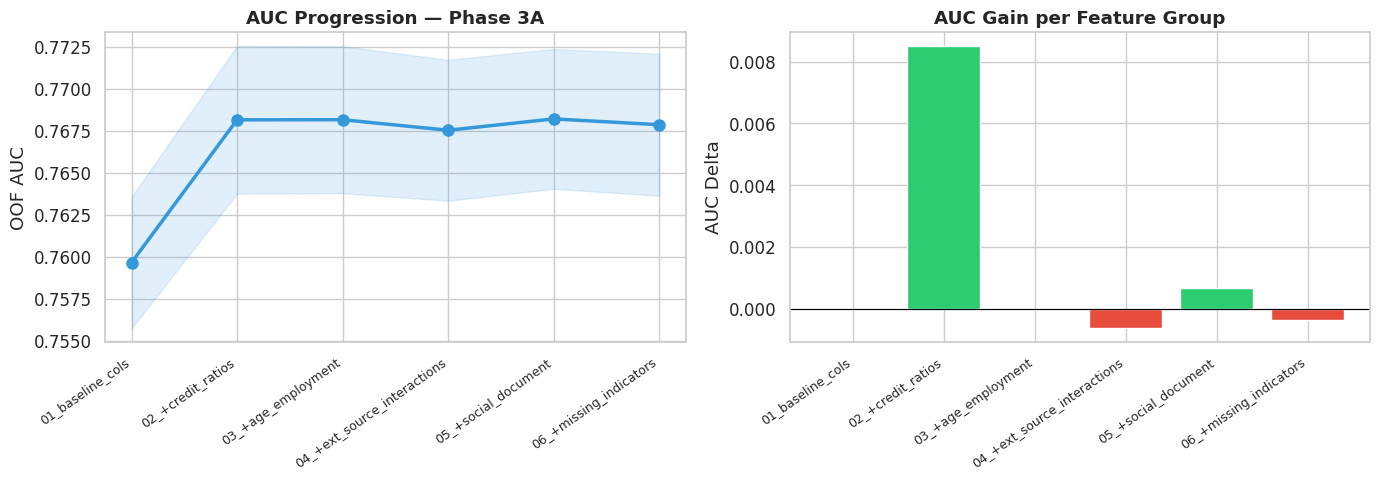

In [36]:
# ── Experiment Log ────────────────────────────────────────────────────────────
log_df = pd.DataFrame(experiment_log)
log_df['auc_delta'] = log_df['oof_auc'].diff().round(6)
log_df['auc_delta'].iloc[0] = 0.0

print('\n📋 Phase 3A Experiment Log:')
print(log_df.to_string(index=False))

# Plot AUC progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(log_df['experiment'], log_df['oof_auc'], 'o-', color='#3498db',
             linewidth=2.5, markersize=8)
axes[0].fill_between(range(len(log_df)),
                      log_df['oof_auc'] - log_df['std'],
                      log_df['oof_auc'] + log_df['std'],
                      alpha=0.15, color='#3498db')
axes[0].set_xticklabels(log_df['experiment'], rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('OOF AUC')
axes[0].set_title('AUC Progression — Phase 3A', fontweight='bold')

colors_delta = ['#2ecc71' if x >= 0 else '#e74c3c' for x in log_df['auc_delta']]
axes[1].bar(log_df['experiment'], log_df['auc_delta'], color=colors_delta)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticklabels(log_df['experiment'], rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('AUC Delta')
axes[1].set_title('AUC Gain per Feature Group', fontweight='bold')

plt.tight_layout()
plt.show()

In [37]:
# Save the full engineered train and test for Phase 3B
# Phase 3B will merge supplementary table aggregations onto these

train_fe['TARGET'] = y  # Re-attach target

train_fe.to_parquet('train_phase3a.parquet', index=False)
test_fe.to_parquet('test_phase3a.parquet',   index=False)

print(f'✅ Saved train_phase3a.parquet : {train_fe.shape}')
print(f'✅ Saved test_phase3a.parquet  : {test_fe.shape}')
print('\n→ Load these in Phase 3B notebook to continue building features.')

✅ Saved train_phase3a.parquet : (307511, 168)
✅ Saved test_phase3a.parquet  : (48744, 167)

→ Load these in Phase 3B notebook to continue building features.
